## NOURA EL KHOLTI

# Support Vector Machine (SVM)

Le SVM (Support Vector Machine) est un algorithme de classification supervisée qui cherche à séparer des données en deux classes à l’aide d’une frontière linéaire (ou non linéaire).

## 1. Génération du dataset

In [1]:

import numpy as np
import matplotlib.pyplot as plt

def generate_dataset(n_simples=100, c_pos=(2, -2), c_neg=(-2, 2), seed=13):
    """
    Génère un dataset simple et linéairement séparable.
    """

    if n_simples % 2 != 0:
        raise ValueError("Le nombre d'échantillons doit être pair")

    np.random.seed(seed)

    # Centres des deux classes
    # Chaque classe est centrée autour d'un point différent
    c_pos = np.array(c_pos)
    c_neg = np.array(c_neg)

    # Génération des points
    # On crée deux nuages de points suivant une distribution normale (Gaussienne)
    # puis on les décale autour de leurs centres respectifs
    X_pos = np.random.randn(n_simples // 2, 2) + c_pos
    X_neg = np.random.randn(n_simples // 2, 2) + c_neg

    # Fusion des deux classes pour former le dataset final
    X = np.vstack((X_pos, X_neg))

    # Création des labels
    # +1 pour la classe positive
    # -1 pour la classe négative
    y = np.concatenate((
        np.full(n_simples // 2,  1),
        np.full(n_simples // 2, -1)
    ))

    return X, y

## 2. Entraînement du SVM

In [2]:
def train_linear_svm(X, y, learning_rate=0.001, lambda_param=0.01, n_epochs=1000):
    """
    Entraînement du SVM
    """

    n_samples, n_features = X.shape

    # Initialisation des paramètres
    # w : vecteur de poids (définit l'orientation de la frontière)
    # b : biais (déplace la frontière)
    w = np.zeros(n_features)
    b = 0.0

    # Boucle d'entraînement
    for _ in range(n_epochs):
        for i in range(n_samples):

            # Calcul du margin
            # mesure à quel point le point est bien classé
            margin = y[i] * (np.dot(X[i], w) + b)

            # Cas 1 : point bien classé avec marge suffisante
            if margin >= 1:
                # Pas d'erreur, seulement régularisation
                # On réduit légèrement w pour maximiser la marge
                # Only regularization term
                w -= learning_rate * (2 * lambda_param * w)

            # Cas 2 : point mal classé ou dans la marge
            else:
                # On corrige l'erreur + régularisation
                w -= learning_rate * (2 * lambda_param * w - X[i] * y[i])

                # Mise à jour du biais pour corriger le déplacement
                b += learning_rate * y[i]

    return w, b

## 3. Fonction de prédiction

In [3]:
def predict(X, w, b):
    """
    Prédit la classe d'un ensemble de points X en utilisant le modèle linéaire appris.
    """
    return np.sign(np.dot(X, w) + b)

## 4. Évaluation du modèle

In [4]:
# Génération des données
X, y = generate_dataset()

# Entraînement du modèle
w, b = train_linear_svm(X, y)

# Prédiction sur les mêmes données
y_pred = predict(X, w, b)

# Calcul de l'accuracy
accuracy = np.mean(y_pred == y)

print("Weights:", w)
print("Bias:", b)
print("Accuracy:", accuracy)

Weights: [ 0.70206355 -0.72531682]
Bias: 0.11300000000000009
Accuracy: 1.0


## 5. Visualisation du dataset et de la frontière SVM

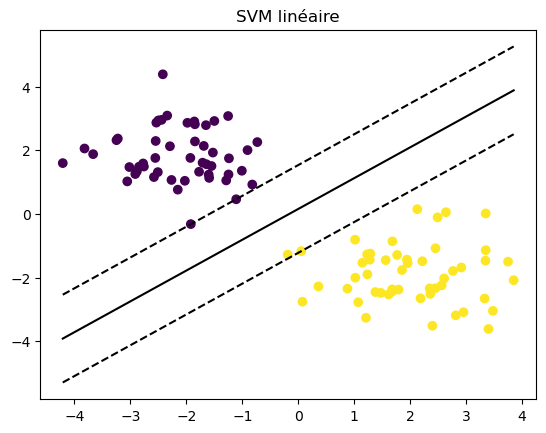

In [5]:
# Affichage des points du dataset
# Chaque point est coloré selon sa classe (+1 ou -1)
plt.scatter(X[:, 0], X[:, 1], c=y)

# Génération d'un ensemble de valeurs pour tracer des lignes continues
x = np.linspace(X[:, 0].min(), X[:, 0].max(), 100)

# Frontière de décision du SVM
y0 = -(w[0] * x + b) / w[1]

# Merges du SVM
y_pos = -(w[0] * x + b - 1) / w[1]
y_neg = -(w[0] * x + b + 1) / w[1]

# Tracé de la frontière de décision
plt.plot(x, y0, 'k')

# Tracé des marges (lignes pointillées)
plt.plot(x, y_pos, 'k--')
plt.plot(x, y_neg, 'k--')

plt.title("SVM linéaire")

# Affichage final
plt.show()